# Analyse du Générateur os.urandom (Hasard Système)



In [5]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare

N = 50000
data_urandom = [int.from_bytes(os.urandom(1), 'big') for _ in range(N)]

print(f"Génération terminée : {len(data_urandom)} octets récupérés via le système.")
print(f"Aperçu (10 premiers) : {data_urandom[:10]}")

Génération terminée : 50000 octets récupérés via le système.
Aperçu (10 premiers) : [149, 236, 139, 40, 107, 242, 70, 141, 125, 220]


## 1. Distribution des Fréquences



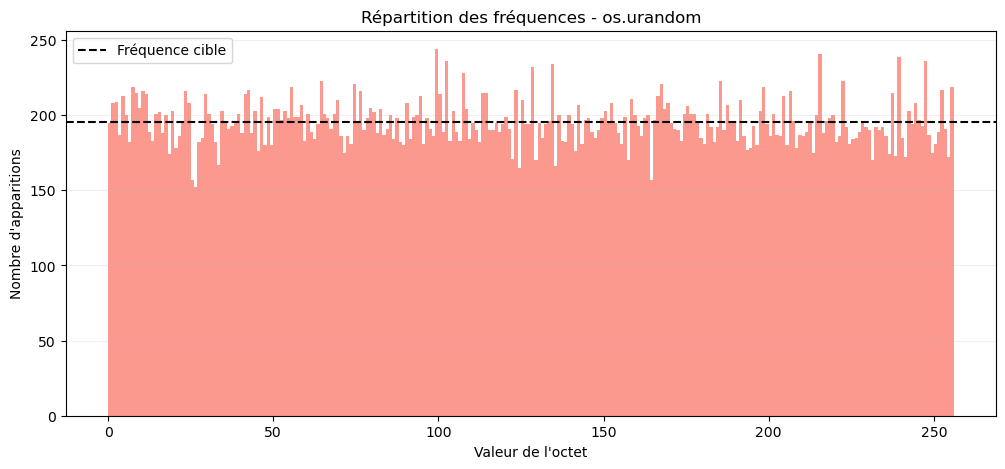

In [6]:
plt.figure(figsize=(12, 5))
plt.hist(data_urandom, bins=256, range=(0, 256), color='salmon', alpha=0.8, edgecolor='none')
plt.axhline(y=N/256, color='black', linestyle='--', label='Fréquence cible')

plt.title("Répartition des fréquences - os.urandom")
plt.xlabel("Valeur de l'octet")
plt.ylabel("Nombre d'apparitions")
plt.legend()
plt.grid(axis='y', alpha=0.2)
plt.show()

## 2. Analyse de l'Entropie de Shannon


In [7]:
def calculate_shannon_entropy(data):
    _, counts = np.unique(data, return_counts=True)
    probs = counts / len(data)
    return -np.sum(probs * np.log2(probs))

entropy_os = calculate_shannon_entropy(data_urandom)
print(f"Entropie de Shannon : {entropy_os:.5f} bits/octet")
print(f"Qualité du hasard : {(entropy_os / 8.0) * 100:.4f}%")

Entropie de Shannon : 7.99590 bits/octet
Qualité du hasard : 99.9487%


## 3. Test Statistique du $\chi^2$ (Chi-carré)



In [8]:
# Fréquences observées
obs, _ = np.histogram(data_urandom, bins=256, range=(0, 256))

# Calcul du test
stat, p_value = chisquare(obs)

print(f"Statistique Chi2 : {stat:.2f}")
print(f"P-value : {p_value:.5f}")

if p_value > 0.05:
    print("Verdict : Uniformité validée (p > 0.05).")
else:
    print("Verdict : Échec inattendu du test d'uniformité.")

Statistique Chi2 : 286.38
P-value : 0.08606
Verdict : Uniformité validée (p > 0.05).


## 4. Analyse de l'Autocorrélation



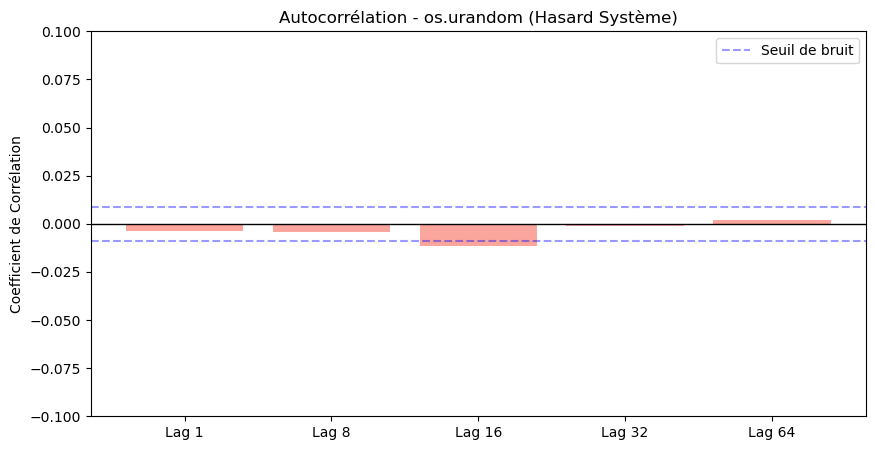

Lag 1 : -0.003519
Lag 8 : -0.004267
Lag 16 : -0.011565
Lag 32 : -0.001303
Lag 64 : 0.001765


In [9]:
def plot_autocorr_os(data, lags=[1, 8, 16, 32, 64]):
    corrs = [np.corrcoef(data[:-lag], data[lag:])[0, 1] for lag in lags]
    
    plt.figure(figsize=(10, 5))
    plt.bar([f"Lag {l}" for l in lags], corrs, color='salmon', alpha=0.7)
    plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
    conf_interval = 1.96 / np.sqrt(len(data))
    plt.axhline(y=conf_interval, color='blue', linestyle='--', alpha=0.4, label='Seuil de bruit')
    plt.axhline(y=-conf_interval, color='blue', linestyle='--', alpha=0.4)
    
    plt.title("Autocorrélation - os.urandom (Hasard Système)")
    plt.ylabel("Coefficient de Corrélation")
    plt.ylim(-0.1, 0.1)
    plt.legend()
    plt.show()

    for l, c in zip(lags, corrs):
        print(f"Lag {l} : {c:.6f}")

plot_autocorr_os(data_urandom)

## 4. Test de Kolmogorov-Smirnov (KS)


In [10]:
from scipy.stats import kstest

data_norm = np.array(data_urandom) / 255.0

statistic_ks, p_value_ks = kstest(data_norm, 'uniform')

print(f"Statistique KS : {statistic_ks:.5f}")
print(f"P-value KS : {p_value_ks:.5f}")

if p_value_ks > 0.05:
    print("\nVerdict : L'uniformité de os.urandom est validée (Succès).")
else:
    print("\nVerdict : Le test détecte une anomalie dans la distribution (Échec).")

Statistique KS : 0.00612
P-value KS : 0.04690

Verdict : Le test détecte une anomalie dans la distribution (Échec).
